## PCA auf Basis des USA arrest data sets

### Datensatz untersuchen

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ISLP import load_data

USArrests : pd.DataFrame = get_rdataset('USArrests').data
USArrests.describe().round(2)

,Murder,Assault,UrbanPop,Rape
count,50.00,50.00,50.00,50.00
mean,7.79,170.76,65.54,21.23
std,4.36,83.34,14.47,9.37
min,0.80,45.00,32.00,7.30
25%,4.08,109.00,54.50,15.08
50%,7.25,159.00,66.00,20.10
75%,11.25,249.00,77.75,26.18
max,17.40,337.00,91.00,46.00


### Durchführung PCA

In [2]:
scaler = StandardScaler(with_std=True, with_mean=True)
USArrests_scaled = scaler.fit_transform(USArrests)

pcaUS = PCA() #alternativ: pcaUS = PCA(n_components=2)
pcaUS.fit(USArrests_scaled)
pcaUS.mean_

#Hauptkomponentenscores berechnen
scores = pcaUS.transform(USArrests_scaled)
pcaUS.components_

array([[ 0.53589947,  0.58318363,  0.27819087,  0.54343209],
       [-0.41818087, -0.1879856 ,  0.87280619,  0.16731864],
       [-0.34123273, -0.26814843, -0.37801579,  0.81777791],
       [-0.6492278 ,  0.74340748, -0.13387773, -0.08902432]])

### Matrix Completion mit einer PCA

In [3]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# Step 1: NAs einsetzen
np.random.seed(42)
mask = np.random.rand(*USArrests.shape) < 0.2  # 20% missing
USArrests_missing = USArrests.copy()
USArrests_missing.values[mask] = np.nan  # anwenden

# Spalten in Float konvertieren
USArrests_missing = USArrests_missing.apply(pd.to_numeric)

# Step 2: Zunächst Imputation mit Mittelwert (Bitte darüber nachdenken warum)
imputer = SimpleImputer(strategy='mean')
USArrests_imputed = imputer.fit_transform(USArrests_missing)

# Step 3: PCA anwenden
pca = PCA(n_components=2)
scores = pca.fit_transform(USArrests_imputed)
reconstructed = pca.inverse_transform(scores)

# Step 4: NAs ersetzen
USArrests_completed = USArrests_missing.copy()  
for i, j in zip(*np.where(mask)):  # Nur fehlende Werte updaten
    USArrests_completed.iat[i, j] = reconstructed[i, j]

# Step 5: Ergebnisse vergleichen
true_values = USArrests.values[mask] 
imputed_values = USArrests_completed.values[mask]
rows_mask, columns_mask = np.where(mask)

mse = mean_squared_error(true_values, imputed_values)
rmse = np.sqrt(mse)
print("MSE: ", mse)
print("RMSE: ", rmse)

df = pd.DataFrame({
    'Row' : USArrests.index.values[rows_mask],
    'Column': USArrests.columns.values[columns_mask],
    'Original': true_values,
    'Imputed': imputed_values
})

print("Vergleich")
print(df.head(20))


MSE:  14.36608779891371
RMSE:  3.790262233528666
Vergleich
            Row    Column  Original     Imputed
0        Alaska    Murder      10.0   12.465331
1        Alaska   Assault     263.0  264.200532
2        Alaska  UrbanPop      48.0   52.274457
3       Arizona  UrbanPop      80.0   79.914839
4      Arkansas  UrbanPop      50.0   50.072458
5      Arkansas      Rape      19.5   19.257578
6      Colorado   Assault     204.0  204.762682
7   Connecticut  UrbanPop      77.0   75.351981
8      Delaware   Assault     238.0  237.092587
9      Delaware      Rape      15.8   26.518935
10      Florida    Murder      15.4   14.398162
11      Georgia   Assault     211.0  211.529845
12       Hawaii    Murder       5.3    1.547238
13       Hawaii  UrbanPop      83.0   83.544911
14     Illinois   Assault     249.0  248.616785
15         Iowa    Murder       2.2    3.117331
16         Iowa   Assault      56.0   55.921951
17         Iowa  UrbanPop      57.0   56.919415
18     Kentucky  UrbanPop    

C:\Users\jakob\AppData\Local\Temp\ipykernel_16332\2557721244.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '264.2005321105461' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  USArrests_completed.iat[i, j] = reconstructed[i, j]
C:\Users\jakob\AppData\Local\Temp\ipykernel_16332\2557721244.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '52.27445707545864' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  USArrests_completed.iat[i, j] = reconstructed[i, j]


## K-means Iris

### 2 Cluster

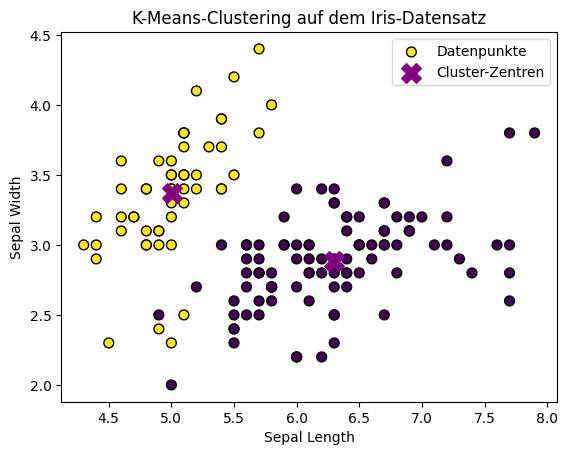

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

# 1. Laden des Iris-Datensatzes
iris_data = load_iris().data

# 2. K-Means-Clustering
kmeans = KMeans(n_clusters=2, random_state=999) # Anzahl Cluster 2, random state 999
kmeans.fit(iris_data)

labels = kmeans.labels_ # Clusterzuweisungen für jeden Datenpunkt
centroids = kmeans.cluster_centers_ # Koordinaten der berechneten Clusterzentren

# 3. Visualisierung der Cluster
plt.scatter(iris_data[:, 0], iris_data[:, 1], c=labels, cmap='viridis', marker='o', edgecolor='k', s=50, label="Datenpunkte")
plt.scatter(centroids[:, 0], centroids[:, 1], c='purple', marker='X', s=200, label="Cluster-Zentren")
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.title('K-Means-Clustering auf dem Iris-Datensatz')
plt.show()

### 3 Cluster

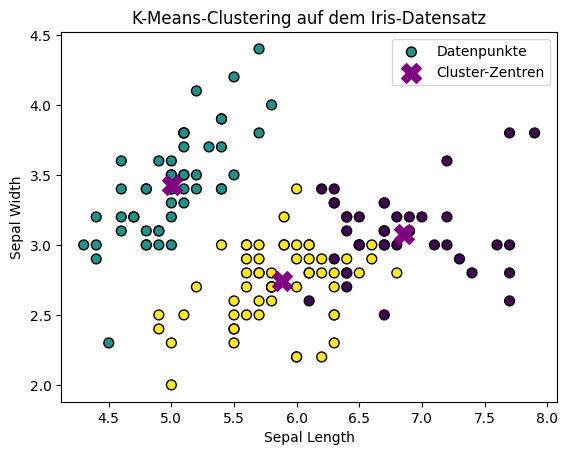

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

# 1. Laden des Iris-Datensatzes
iris_data = load_iris().data

# 2. K-Means-Clustering
kmeans = KMeans(n_clusters=3, random_state=999) # Anzahl Cluster 3, random state 999
kmeans.fit(iris_data)

labels = kmeans.labels_ # Clusterzuweisungen für jeden Datenpunkt
centroids = kmeans.cluster_centers_ # Koordinaten der berechneten Clusterzentren

# 3. Visualisierung der Cluster
plt.scatter(iris_data[:, 0], iris_data[:, 1], c=labels, cmap='viridis', marker='o', edgecolor='k', s=50, label="Datenpunkte")
plt.scatter(centroids[:, 0], centroids[:, 1], c='purple', marker='X', s=200, label="Cluster-Zentren")
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.title('K-Means-Clustering auf dem Iris-Datensatz')
plt.show()

### 4 Cluster

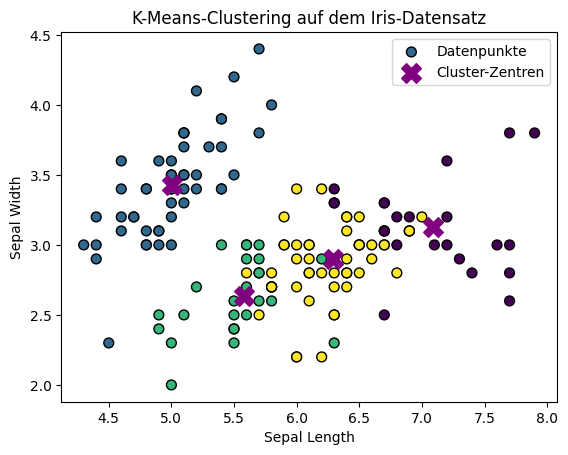

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

# 1. Laden des Iris-Datensatzes
iris_data = load_iris().data

# 2. K-Means-Clustering
kmeans = KMeans(n_clusters=4, random_state=999) # Anzahl Cluster 4, random state 999
kmeans.fit(iris_data)

labels = kmeans.labels_ # Clusterzuweisungen für jeden Datenpunkt
centroids = kmeans.cluster_centers_ # Koordinaten der berechneten Clusterzentren

# 3. Visualisierung der Cluster
plt.scatter(iris_data[:, 0], iris_data[:, 1], c=labels, cmap='viridis', marker='o', edgecolor='k', s=50, label="Datenpunkte")
plt.scatter(centroids[:, 0], centroids[:, 1], c='purple', marker='X', s=200, label="Cluster-Zentren")
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.title('K-Means-Clustering auf dem Iris-Datensatz')
plt.show()